In [1]:
%matplotlib inline

from glob import glob
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

In [2]:
LABELS = {
    'rej.enc'       : 'Fast Loaded Dice Roller (FLDR)',
    'alias.exact'   : 'Exact Alias Sampler',
    'alias.integers_old' : 'Alias Integers',
    'aldr'          : 'ALDR',
    'alias.rust'    : 'Alias Rust',
    'alias.fractions' : 'Alias Fractions',
    'alias.integers_gmp' : 'Alias Integers (GMP)',
}

In [3]:
def parse_decimal(value):
    if hasattr(value, "decode"):
        value = value.decode()
    return float(value.replace(",", "."))

In [4]:
# Load metadata from the fixed distribution folder
dists_dir = os.path.abspath(os.path.join('..', 'distributions_n'))

if not os.path.isdir(dists_dir):
    print(f'Directory not found: {dists_dir}')
    n_values = None
    entropies_per_dist = None
    Z_values = None
    avg_entropy = None
    f_runtimes = []
    f_sizes = []
    f_bits = []
else:
    print(f'Using directory: {dists_dir}')

    # Load metadata.json
    metadata_path = os.path.join(dists_dir, 'metadata.json')
    if os.path.exists(metadata_path):
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)
        n_values = np.asarray(metadata.get('n_values', []))
        entropies_per_dist = np.asarray(metadata.get('entropies', []))
        Z_values = np.asarray(metadata.get('Z_values', []))
        avg_entropy = metadata.get('avg_entropy', None)
        print(f'Loaded metadata: {len(n_values)} distributions')
    else:
        print(f'metadata.json not found at {metadata_path}')
        n_values = None
        entropies_per_dist = None
        Z_values = None
        avg_entropy = None

    # Load runtime and size files
    f_runtimes = sorted(glob(os.path.join(dists_dir, '*.runtimes')))
    f_sizes = sorted(glob(os.path.join(dists_dir, '*.sizes')))
    f_bits = sorted(glob(os.path.join(dists_dir, '*.bits')))

# Load runtime and size arrays (safe defaults if lists are empty)
if f_runtimes:
    runtimes = np.asarray([np.loadtxt(f) for f in f_runtimes])
else:
    runtimes = np.empty((0,))

if f_sizes:
    sizes = np.asarray([np.loadtxt(f) for f in f_sizes])
else:
    sizes = np.empty((0,))

if f_bits:
    bits = np.asarray([np.loadtxt(f, converters={0: parse_decimal}) for f in f_bits])
else:
    bits = np.empty((0,))

num_samples = 1e6
rates = runtimes / num_samples if runtimes.size else np.empty((0,))
samplers = [os.path.basename(x).replace('.runtimes', '') for x in f_runtimes]

print(f'Samplers: {samplers}')
print(f'Runtimes shape: {runtimes.shape}')
print(f'n_values: {n_values[:5] if n_values is not None else None}')

Using directory: /Users/oriane/Documents/code/FLDR-experiments/experiments/distributions_n
Loaded metadata: 99 distributions
Samplers: ['aldr', 'alias.exact', 'alias.integers_old', 'alias.rust', 'rej.enc']
Runtimes shape: (5, 99)
n_values: [1000 2000 3000 4000 5000]


In [5]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

#### Plot Memory--Rate (vs n)

In [6]:
selection = [
    'alias.integers_old',
    'aldr',
    'alias.rust',
    'alias.fractions',
    'alias.exact',
    'rej.enc',
]

Plotting aldr: 99 points
Plotting alias.exact: 99 points
Plotting alias.integers_old: 99 points
Plotting alias.rust: 99 points
Plotting rej.enc: 99 points


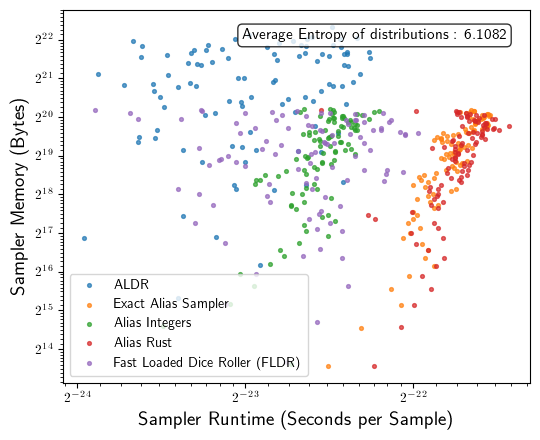

In [7]:
def run_plot_rate_size_vs_n(samplers, rates, sizes, avg_entropy):
    """Plot sampler runtime vs memory for each n value."""
    fig, ax = plt.subplots()
    collections = []
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for idx, (sampler, rate, size) in enumerate(zip(samplers, rates, sizes)):
        if sampler not in selection:
            continue
        color = colors[idx % len(colors)]
        print(f'Plotting {sampler}: {len(rate)} points')
        sc = ax.scatter(rate, size, color=color, label=LABELS[sampler], s=30, marker='.', alpha=0.7)
        collections.append((sampler, sc))

    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)

    ax.set_xlabel('Sampler Runtime (Seconds per Sample)', fontsize=14)
    ax.set_ylabel('Sampler Memory (Bytes)', fontsize=14)

    ax.xaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=100))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.xaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11, 20)*.1, numticks=24))

    ax.yaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=20))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11,20)*.1, numticks=100))

    fig.set_size_inches((8, 6))
    fig.set_facecolor('white')
    fig.set_tight_layout(True)

    return fig, ax, collections

if n_values is not None:
    fig, ax, collections = run_plot_rate_size_vs_n(samplers, rates, sizes, avg_entropy)
    ax.legend(loc='best')
    legend_text = f'Average Entropy of distributions : {avg_entropy:.4f}' if avg_entropy is not None else 'Average Entropy of distributions: N/A'
    ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    fig.set_tight_layout(True)
    fig.set_size_inches(5.5, 4.5)
    for ext in ['pdf', 'png']:
        fig.savefig(f'figure-4-n-interpolation-runtime-memory.{ext}')
    plt.show()
else:
    print('Cannot plot: n_values not loaded')


#### Plot Rate vs n

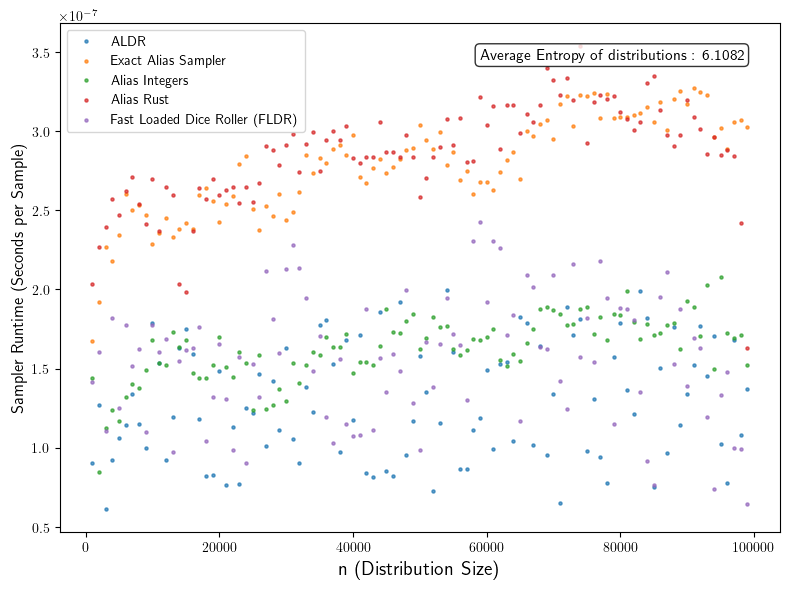

In [8]:
def run_plot_rate_vs_n(samplers, n_values, rates):
    """Plot sampler runtime (rate) vs n for each sampler."""
    fig, ax = plt.subplots()

    for sampler, rate in zip(samplers, rates):
        if sampler not in selection:
            continue

        ax.scatter(n_values, rate, label=LABELS[sampler], marker='.', s=20, alpha=0.7)

    ax.set_xlabel('n (Distribution Size)', fontsize=14)
    ax.set_ylabel('Sampler Runtime (Seconds per Sample)', fontsize=12)
    ax.legend(loc='best')

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))
    return fig, ax

if n_values is not None:
    fig, ax = run_plot_rate_vs_n(samplers, n_values, rates)
    legend_text = f'Average Entropy of distributions : {avg_entropy:.4f}' if avg_entropy is not None else 'Average Entropy of distributions: N/A'
    ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    for ext in ['pdf', 'png']:
        fig.savefig(f'figure-4-n-interpolation-rate-vs-n.{ext}')
    plt.show()
else:
    print('Cannot plot: n_values not loaded')


#### Plot Memory vs n

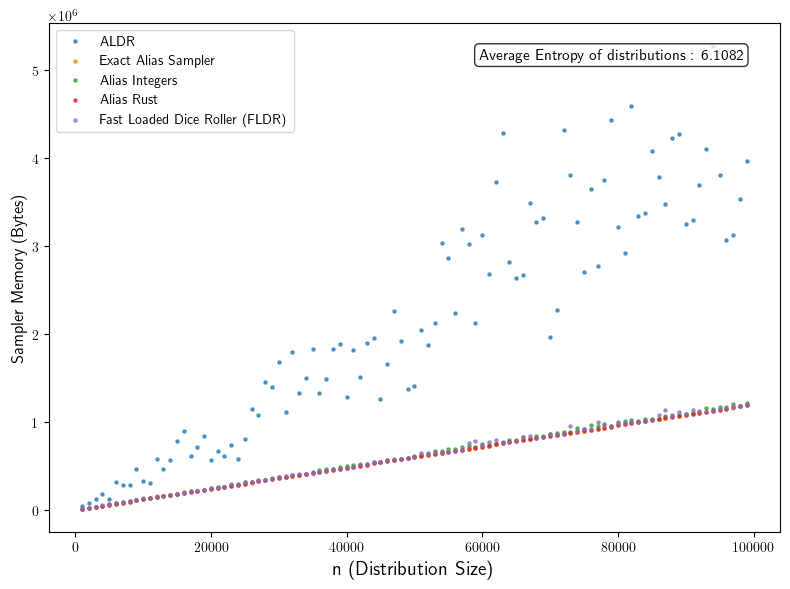

In [9]:
def run_plot_memory_vs_n(samplers, n_values, sizes):
    """Plot sampler memory vs n for each sampler."""
    fig, ax = plt.subplots()

    for sampler, size in zip(samplers, sizes):
        if sampler not in selection:
            continue

        ax.scatter(n_values, size, label=LABELS[sampler], marker='.', s=20, alpha=0.7)

    ax.set_xlabel('n (Distribution Size)', fontsize=14)
    ax.set_ylabel('Sampler Memory (Bytes)', fontsize=12)
    ax.legend(loc='best')

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))
    return fig, ax

if n_values is not None:
    fig, ax = run_plot_memory_vs_n(samplers, n_values, sizes)
    legend_text = f'Average Entropy of distributions : {avg_entropy:.4f}' if avg_entropy is not None else 'Average Entropy of distributions: N/A'
    ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    for ext in ['pdf', 'png']:
        fig.savefig(f'figure-4-n-interpolation-memory-vs-n.{ext}')
    plt.show()
else:
    print('Cannot plot: n_values not loaded')


#### Plot Bits vs n

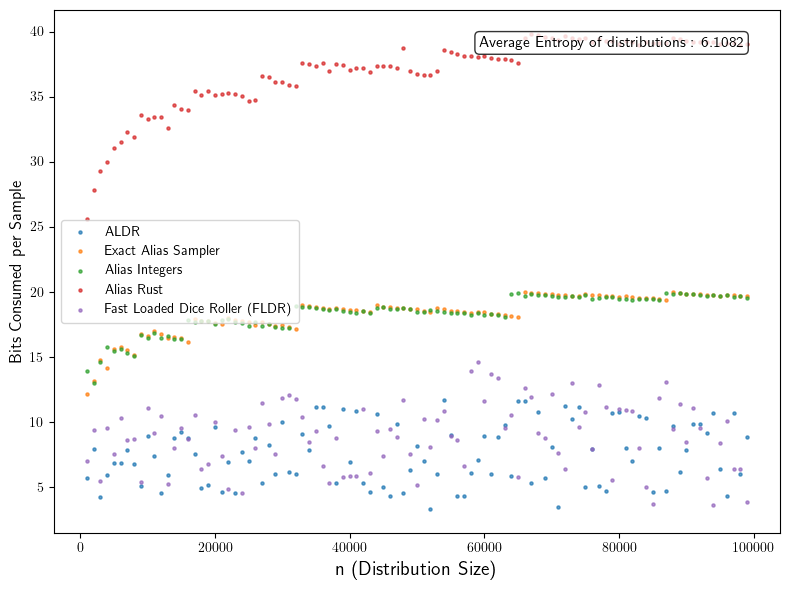

In [10]:
def run_plot_bits_vs_n(samplers, n_values, bits):
    """Plot bits consumed vs n for each sampler."""
    fig, ax = plt.subplots()

    for sampler, bit in zip(samplers, bits):
        if sampler not in selection:
            continue

        ax.scatter(n_values, bit, label=LABELS[sampler], marker='.', s=20, alpha=0.7)

    ax.set_xlabel('n (Distribution Size)', fontsize=14)
    ax.set_ylabel('Bits Consumed per Sample', fontsize=12)
    ax.legend(loc='best')

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))
    return fig, ax

if n_values is not None:
    fig, ax = run_plot_bits_vs_n(samplers, n_values, bits)
    legend_text = f'Average Entropy of distributions : {avg_entropy:.4f}' if avg_entropy is not None else 'Average Entropy of distributions: N/A'
    ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    for ext in ['pdf', 'png']:
        fig.savefig(f'figure-4-n-interpolation-bits-vs-n.{ext}')
    plt.show()
else:
    print('Cannot plot: n_values not loaded')

#### Plot Bits vs Runtime (Rate)

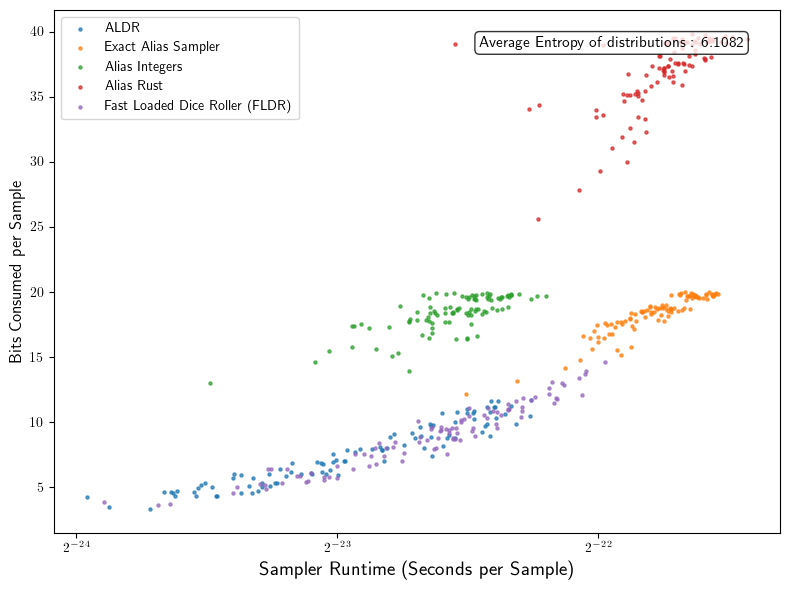

In [11]:
def run_plot_bits_vs_rate(samplers, rates, bits):
    """Plot bits consumed vs runtime (rate) for each sampler."""
    fig, ax = plt.subplots()

    for sampler, rate, bit in zip(samplers, rates, bits):
        if sampler not in selection:
            continue

        ax.scatter(rate, bit, label=LABELS[sampler], marker='.', s=20, alpha=0.7)

    ax.set_xscale('log', base=2)
    ax.set_xlabel('Sampler Runtime (Seconds per Sample)', fontsize=14)
    ax.set_ylabel('Bits Consumed per Sample', fontsize=12)
    ax.legend(loc='best')

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))
    return fig, ax

if n_values is not None:
    fig, ax = run_plot_bits_vs_rate(samplers, rates, bits)
    legend_text = f'Average Entropy of distributions : {avg_entropy:.4f}' if avg_entropy is not None else 'Average Entropy of distributions: N/A'
    ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    for ext in ['pdf', 'png']:
        fig.savefig(f'figure-4-n-interpolation-bits-vs-rate.{ext}')
    plt.show()
else:
    print('Cannot plot: n_values not loaded')